In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import casadi as ca
%matplotlib widget

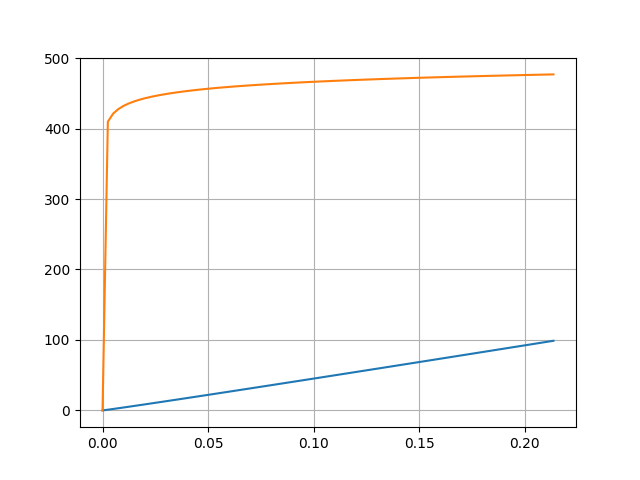

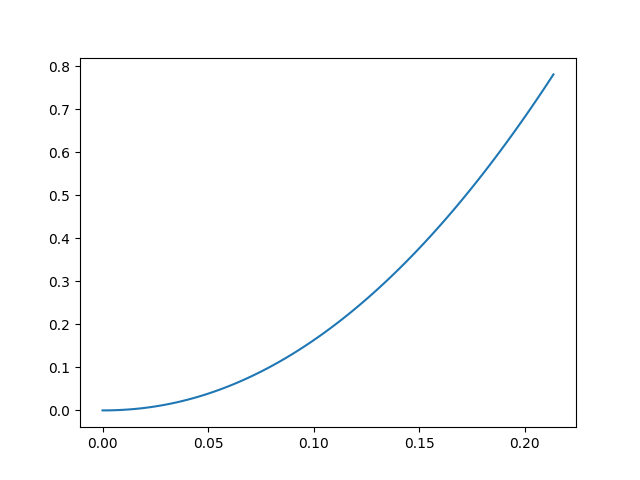

In [151]:
def dynamics(t, x, p):
    theta = x[0]
    theta_d = x[1]
    L = p[0]
    r = p[1]
    m = p[2]
    tau_max = p[3]
    w_max = p[4]

    torque = tau_max*(1 - theta_d / w_max)
    mech_adv = L / (r**2 * theta)
    force = mech_adv * torque
    theta_dd = force / m
    return [theta_d, theta_dd]

def dynamics_ca(t, x, p):
    theta_d, theta_dd = dynamics(t, x, p)
    return ca.vertcat(theta_d, theta_dd)

def num_integration(theta_init, T_val, params, theta_max, N_points=200):
    """
    Returns trajectory tuples: (thetas, theta_ds) using scipy.integrate.solve_ivp.
    The solution is sampled at N_points between t=0 and T_val.
    """
    def theta_max_event(t, x):
        theta, theta_d = x
        return theta_max - theta 
    theta_max_event.terminal=True
    theta_max_event.direction=-1 #going from postive to negative
    
    t_eval = np.linspace(0, T_val, N_points)
    y0 = [theta_init, 0.0]
    sol = solve_ivp(lambda t, x: dynamics(t, x, params), [0, T_val], y0, events=theta_max_event, t_eval=t_eval, method='RK45', vectorized=False)

    # Only use the t_eval points up to where the integration stopped (sol.t)
    # sol.t may be shorter than t_eval if the event was triggered
    thetas = sol.y[0]
    theta_ds = sol.y[1]
    return sol.t, thetas, theta_ds

# Set initial guess for [T, L, tau_max, r, m, w_max]
x0 = [
    0.5,  # T
    0.050, # L
    0.002, # r
    0.4,  # m
    0.2795,  # tau_max
    1704  # w_max
]

t_eval, thetas_num, theta_ds_num = num_integration(theta_init=1e-5, T_val=x0[0], params=x0[1:], theta_max=100)

plt.figure()
plt.plot(t_eval, thetas_num)
plt.plot(t_eval, theta_ds_num)
plt.grid()
plt.show()

L = x0[1]
r = x0[2]
mech_adv = L / (r**2 * thetas_num)
output_vel = thetas_num / mech_adv
plt.figure()
plt.plot(t_eval, output_vel)
plt.show()

In [40]:
import casadi as ca


# Define symbols for parameters
L = ca.MX.sym('L')
tau_max = ca.MX.sym('tau_max')
r = ca.MX.sym('r')
m = ca.MX.sym('m')
w_max = ca.MX.sym('w_max')

# Parameter vector
params = ca.vertcat(L, tau_max, r, m, w_max)

# Total integration time (unknown, will be optimization variable)
T = ca.MX.sym('T')

# Time step
N = 100
dt = T / N

# Initial state
theta_init = 1
current_x = ca.vertcat(theta_init, 0.0) # [theta, theta_d]

# RK4 Integration Loop
for _ in range(N):
    k1 = dynamics_ca(_, current_x, params)
    k2 = dynamics_ca(_, current_x + 0.5 * dt * k1, params)
    k3 = dynamics_ca(_, current_x + 0.5 * dt * k2, params)
    k4 = dynamics_ca(_, current_x + dt * k3, params)
    
    current_x = current_x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    
theta_f = current_x[0]
theta_d_f = current_x[1]

In [213]:
def rk4_integrate(T, params, N, theta_init=1):
    """
    Integrates the system dynamics using RK4.
    
    Args:
        T: Total time (CasADi expression or float)
        params: Parameter vector [L, tau_max, r, m, w_max]
        N: Number of steps
        theta_init: Initial angle
        
    Returns:
        tuple: (theta_final, theta_d_final) as CasADi expressions
    """
    dt = T / N
    current_x = ca.vertcat(theta_init, 0.0) # [theta, theta_d]
    
    for _ in range(N):
        k1 = dynamics_ca(_, current_x, params)
        k2 = dynamics_ca(_, current_x + 0.5 * dt * k1, params)
        k3 = dynamics_ca(_, current_x + 0.5 * dt * k2, params)
        k4 = dynamics_ca(_, current_x + dt * k3, params)
        
        current_x = current_x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        
    return current_x[0], current_x[1]

def setup_opti(N, guess, m_val, tau_max_val, w_max_val):
    """
    Sets up the optimization problem using CasADi Opti stack.
    tau_max, m, and w_max are treated as constant parameters.
    """
    opti = ca.Opti()
    
    # Variables
    T = opti.variable()
    L = opti.variable()
    r = opti.variable()
    
    # Parameters
    m = opti.parameter()
    tau_max = opti.parameter()
    w_max = opti.parameter()
    
    # Set parameter values
    opti.set_value(m, m_val)
    opti.set_value(tau_max, tau_max_val)
    opti.set_value(w_max, w_max_val)
    
    params = ca.vertcat(L, r, m, tau_max, w_max)
    
    # Dynamics constraints
    theta_f, theta_d_f = rk4_integrate(T, params, N=N)
    
    # Objective
    mech_adv = L / (r**2 * theta_f)
    output_vel = theta_d_f / mech_adv
    opti.minimize(-output_vel)
    
    # Constraints
    L_end = L*0.3
    theta_max = ca.sqrt(L**2 - L_end**2)/r
    opti.subject_to(theta_f == theta_max)
    
    # Bounds
    opti.subject_to(T >= 0.001)
    opti.subject_to(T <= 2.0)
    opti.subject_to(L >= 0.010)
    opti.subject_to(L <= 0.100)
    opti.subject_to(r >= 0.0001)
    opti.subject_to(r <= 0.050)
    
    # Initial guess
    opti.set_initial(T, guess[0])
    opti.set_initial(L, guess[1])
    opti.set_initial(r, guess[2])
    
    # Solver options
    opts = {'ipopt.print_level': 0, 'print_time': 0}
    opti.solver('ipopt', opts)
    
    return opti, {'T': T, 'L': L, 'r': r, 'm': m, 'tau_max': tau_max, 'w_max': w_max}


guess = [0.5, 0.050, 0.002] #T,L,R
m_val=0.1
tau_max_val=0.2795
w_max_val=1704.0

opti, vars_dict = setup_opti(N=100, guess=guess, m_val=m_val, tau_max_val=tau_max_val, w_max_val=w_max_val)
sol = opti.solve()
print(f"Final velocity: {-sol.value(opti.f):.4f} m/s")
for name in ['T', 'L', 'r', 'm', 'tau_max', 'w_max']:
    print(f"{name}: {sol.value(vars_dict[name]):.4f}")

Final velocity: 1.2136 m/s
T: 0.0896
L: 0.1000
r: 0.0025
m: 0.1000
tau_max: 0.2795
w_max: 1704.0000


In [207]:
guess

[0.5, 0.05, 0.002]

Guess
theta_max=23.848480035423645
Optimized
theta_max=38.827611197825654
0.10000000962943369 0.0024568580549949185
1.2124077119619252


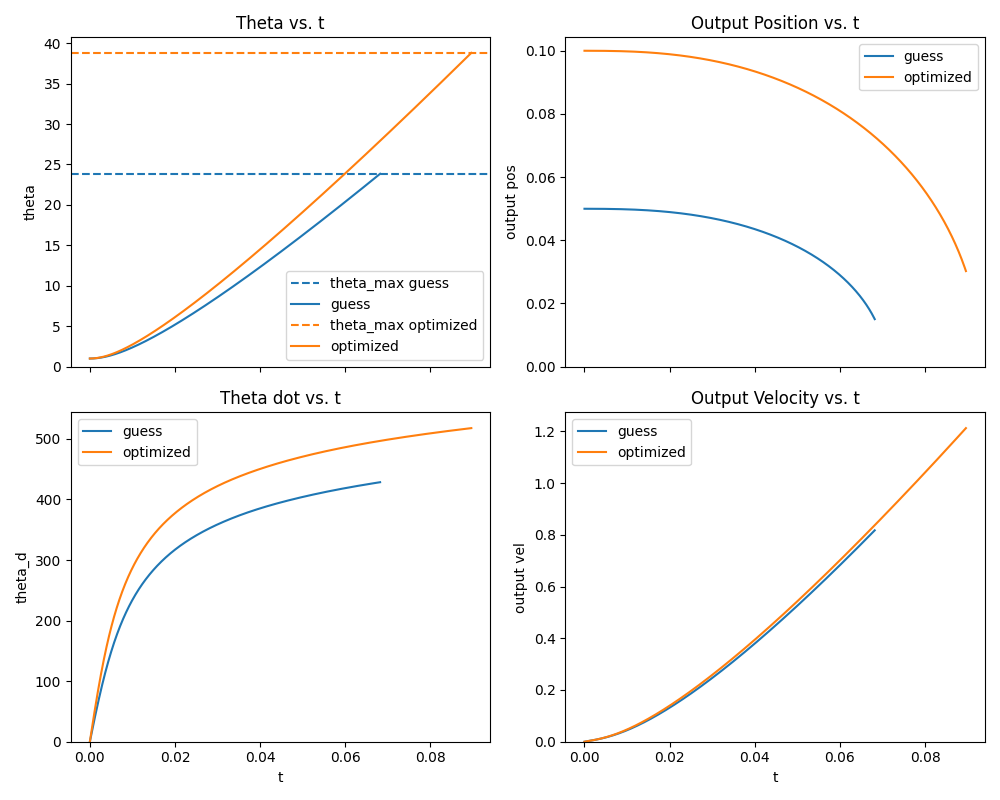

In [212]:
fig, axs = plt.subplots(2, 2, sharex=True, figsize=(10, 8))

print("Guess")
L = guess[1]
r = guess[2]
params = [
    L, # L
    r, # r
    m_val,  # m
    tau_max_val,  # tau_max
    w_max_val  # w_max
]
L_end = L*0.3
theta_max = np.sqrt(L**2 - L_end**2)/r
print(f"theta_max={theta_max}")
axs[0, 0].axhline(theta_max, color='C0', linestyle='--', label='theta_max guess')
t_eval, thetas_num, theta_ds_num = num_integration(theta_init=1, T_val=0.1, params=params, theta_max=theta_max, N_points=1000)
mech_adv = L / (r**2 * thetas_num)
output_pos = np.sqrt(L**2 - (r*thetas_num)**2)
output_vel = theta_ds_num / mech_adv
axs[0, 0].plot(t_eval, thetas_num, label='guess')
axs[1, 0].plot(t_eval, theta_ds_num, label='guess')
axs[0, 1].plot(t_eval, output_pos, label='guess')
axs[1, 1].plot(t_eval, output_vel, label='guess')

print("Optimized")
L = sol.value(vars_dict['L'])
r = sol.value(vars_dict['r'])
params = [
    L, # L
    r, # r
    m_val,  # m
    tau_max_val,  # tau_max
    w_max_val  # w_max
]
L_end = L*0.3
theta_max = np.sqrt(L**2 - L_end**2)/r
axs[0, 0].axhline(theta_max, color='C1', linestyle='--', label='theta_max optimized')
print(f"theta_max={theta_max}")
t_eval, thetas_num, theta_ds_num = num_integration(theta_init=1, T_val=0.1, params=params, theta_max=theta_max, N_points=1000)
print(L, r)
mech_adv_opt = L / (r**2 * thetas_num)
output_pos_opt = np.sqrt(L**2 - (r * thetas_num)**2)
output_vel_opt = theta_ds_num / mech_adv_opt
print(output_vel_opt[-1])
axs[0, 0].plot(t_eval, thetas_num, label='optimized')
axs[1, 0].plot(t_eval, theta_ds_num, label='optimized')
axs[0, 1].plot(t_eval, output_pos_opt, label='optimized')
axs[1, 1].plot(t_eval, output_vel_opt, label='optimized')


axs[0, 0].set_ylabel('theta')
axs[0, 0].set_title('Theta vs. t')
axs[0, 0].set_ylim(0, None)
axs[0, 0].legend()

axs[1, 0].set_ylabel('theta_d')
axs[1, 0].set_xlabel('t')
axs[1, 0].set_title('Theta dot vs. t')
axs[1, 0].set_ylim(0, None)
axs[1, 0].legend()

axs[0, 1].set_ylabel('output pos')
axs[0, 1].set_title('Output Position vs. t')
axs[0, 1].set_ylim(0, None)
axs[0, 1].legend()

axs[1, 1].set_ylabel('output vel')
axs[1, 1].set_xlabel('t')
axs[1, 1].set_title('Output Velocity vs. t')
axs[1, 1].set_ylim(0, None)
axs[1, 1].legend()

plt.tight_layout()
plt.show()

In [112]:
plt.close('all')

In [95]:
params=[guess[1], guess[2], m_val, tau_max_val, w_max_val]
max_theta = np.sqrt(params[0]**2 - (0.1*params[0])**2)
num_integration(theta_init=0.01, T_val=1, params=params, max_theta=max_theta)

(array([0.]), array([0.01]), array([0.]))

In [49]:
sol['x'].full().flatten()

array([1.87662543e-02, 9.99999973e-01, 9.99999973e+00, 9.99990016e-04,
       9.99999936e-02, 1.00000001e+04])